<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/main/2026/HW/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3: Sensor Data Analysis and GitHub Workflow

## Your Personal Physics Experiment

Modern smartphones contain sophisticated sensor arrays capable of capturing high-quality physical measurements. Each student will perform an **experiment** using a specific sensor, then analyze the raw data using Python.

You will also learn the **GitHub feature-branch workflow** by submitting this homework via pull request on the GitHub website.

---

## Learning Outcomes

- Export and analyze **raw sensor data** from phyphox
- Read and preprocess data using pandas
- Fit a physics model specific to your experiment using scipy
- Create publication-quality visualizations with matplotlib
- **Submit homework via pull request using GitHub's web interface**

## Part 1: Experimental Setup with phyphox (10 points)

### Task A: Install and Configure phyphox

1. **Download phyphox**:
   - [iOS App Store](https://apps.apple.com/us/app/phyphox/id1127319693)
   - [Google Play Store](https://play.google.com/store/apps/details?id=de.rwth_aachen.phyphox)

2. **Find your sensor** (based on the table above):
   - Open phyphox
   - Tap the **"+ Custom"** or **"Simple"** tab (NOT the pre-made experiments)
   - Select your assigned sensor (Pressure, Gyroscope, Magnetometer, etc.)

3. **Why raw data?**
   - phyphox has pre-built experiments with automatic analysis
   - We're skipping those to learn **how** the analysis works
   - You'll export the raw CSV and do the fitting yourself

---

### Task B: Perform Your Experiment

Follow the instructions for **your** experiment:

#### **Pressure (Elevator or Bottle)**
- Open "Pressure" sensor
- Start recording
- Ride elevator up/down OR squeeze a sealed water bottle
- Record 30–60 seconds
- Export CSV: `time, pressure`

---

### Task C: Export and Upload

1. **Export data**:
   - In phyphox, tap the **⋮** menu → **Export Data**
   - Choose **CSV** format
   - Save file as `yourusername_hw3_data.csv`

2. **Upload to your workspace**:
   - Use Colab file upload button

---

### Deliverables

- [ ] CSV file with raw sensor data included in your homework folder
- [ ] Brief description (2-3 sentences): What you did, any challenges

To collect the elevator data I went took the elevator in Furnas Hall from the ground floor to the 10th floor. I placed my phone on the ground and did not move it for the duration of the trip.

## Part 2: Data Analysis with pandas (8 points)

### Task: Load and Preprocess

1. **Read CSV** using `pandas.read_csv()`
2. **Inspect**:
   - Print first 10 rows
   - Check for missing values (`df.isnull().sum()`)
   - Verify time spacing (is it uniform?)
3. **Trim data**:
   - Remove initial/final sections where experiment wasn't running
   - For example: cut first 2 seconds (setup time) and last 2 seconds
4. **Select relevant column**:
   - If you have `mag_x, mag_y, mag_z`, pick the axis with largest change
   - If you have `gyro_x, gyro_y, gyro_z`, calculate magnitude or pick dominant axis

---

### Deliverable

- [ ] Code that loads and cleans data
- [ ] Print summary: mean, std, min, max of your measured quantity
- [ ] Explanation: what did you trim and why?

In [1]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
#Loading csv data
df = pd.read_csv('brendanperez_hw3_data.csv')

In [3]:
#Display the first 10 rows
display(df.head(10))

,time,P
0,0.711,985.79
1,1.781,985.79
2,2.850,985.79
3,3.920,985.81
4,4.990,985.84
5,6.061,985.86
6,7.130,985.89
7,8.199,985.92
8,9.269,985.92
9,10.339,985.90


In [4]:
#Check for missing values
display(df.isnull().sum())

,0
time,0
P,0


In [68]:
# Print the difference between each time (s)
display(df.time.diff())

,time
0,NaN
1,1.070
2,1.069
3,1.070
4,1.070
5,1.071
6,1.069
7,1.069
8,1.070
9,1.070


In [6]:
display(df.P.describe())

,P
count,38.000000
mean,983.966842
std,1.769127
min,981.290000
25%,982.272500
50%,984.275000
75%,985.790000
max,985.920000


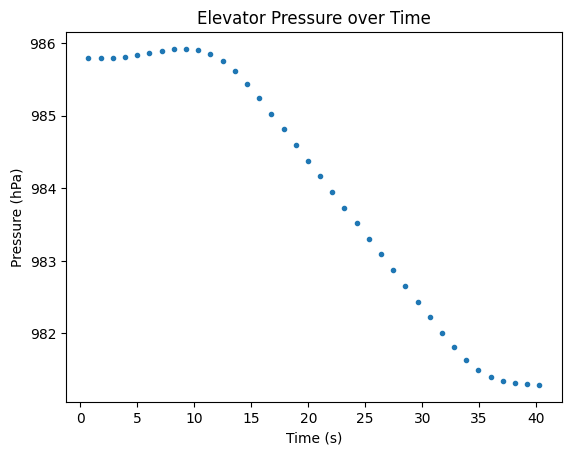

In [8]:
plt.plot(df.time, df.P, '.')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (hPa)')
plt.title('Elevator Pressure over Time')
plt.show()

In [69]:
display(df.P)

,P
0,985.79
1,985.79
2,985.79
3,985.81
4,985.84
5,985.86
6,985.89
7,985.92
8,985.92
9,985.90


To get data only when the elevator was moving, I trimmed the beginning and end. I wanted a section where the data would be linear, as that would give the time when the elevator was moving with constant speed. Rows $14$ to $33$ seem to show the best data.

In [65]:
trimmed_df = df[14:34]

In [66]:
display(trimmed_df.describe())

,time,P
count,20.000000,20.000000
mean,25.849550,983.217000
std,6.326411,1.239652
min,15.688000,981.400000
25%,20.770500,982.167500
50%,25.852000,983.195000
75%,30.929000,984.222500
max,36.005000,985.240000


In [67]:
display(trimmed_df.time)

,time
14,15.688
15,16.758
16,17.828
17,18.898
18,19.968
19,21.038
20,22.107
21,23.177
22,24.247
23,25.317


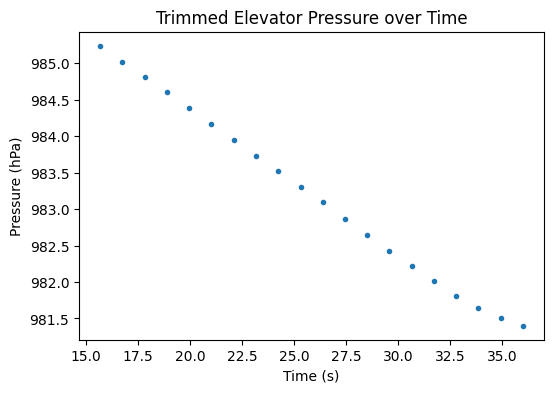

In [111]:
plt.figure(figsize=(6,4))
plt.plot(trimmed_df.time, trimmed_df.P, '.')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (hPa)')
plt.title('Trimmed Elevator Pressure over Time')
plt.show()

## Part 3: Model Fitting (8 points)

### Task A: Define Your Physics Model

Based on **your assigned experiment**, define the appropriate model function:

---

#### **Pressure (Elevator) → Barometric Formula**

Pressure vs altitude:
$$
P(h) = P_0 e^{-h/H}
$$

where $P_0$ is sea-level pressure, $H \approx 8500$ m is scale height.

Convert time to height using $h = v \cdot t$ (elevator speed $v \approx 1$ m/s).

**Fit:** `P(t) = P0 * exp(-v*t / H)`

**Report:** $P_0$ and $v$ (elevator speed)

---

### Task B: Perform the Fit

1. Define your model function in Python
2. Use `scipy.optimize.curve_fit`
3. Extract fitted parameters and uncertainties from covariance matrix

---

### Task C: Plot Data + Fit

Create a plot showing:
- Raw data (scatter plot)
- Fitted curve (solid line)
- Axis labels with units
- Legend
- Title indicating your experiment

---

### Deliverable

- [ ] Model function defined in code
- [ ] `curve_fit` executed successfully
- [ ] Plot with data and fit overlaid
- [ ] Reported parameters with uncertainties (e.g., $\beta = 0.15 \pm 0.02$ s⁻¹)
- [ ] Brief interpretation: Does the fit make sense physically?

In [129]:
#Create a new column to store the height

elevator_speed = 1

trimmed_df['height'] = trimmed_df['height'] * elevator_speed

display(trimmed_df)

/tmp/ipykernel_872/3178755020.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trimmed_df['height'] = trimmed_df['height'] * elevator_speed


,time,P,height
14,15.688,985.24,15.688
15,16.758,985.02,16.758
16,17.828,984.81,17.828
17,18.898,984.60,18.898
18,19.968,984.38,19.968
19,21.038,984.17,21.038
20,22.107,983.95,22.107
21,23.177,983.73,23.177
22,24.247,983.52,24.247
23,25.317,983.30,25.317


In [137]:
H = 8500 # Scale Height

def barometric_formula(height,P0):
  """

  Parameters:
    P0 - float
      The Pressure at sea-level (hPa)
    height - float
      The elevator height (m)

  """
  return P0*np.exp(-height / H)

In [138]:
P0_guess = df.P.max() # hPa, For the initial guess I will use the lowest pressure recorded, which should be when my phone was placed on the ground of the elevator
elevatorSpeed = 1 # m/s, assumed

x = trimmed_df.height
y = trimmed_df.P

popt, pcov = curve_fit(barometric_formula, x, y, p0=[P0_guess])

print('optimal P0 (hPa) - ', popt)
P0 = popt[0]

optimal P0 (hPa) -  [986.21173549]


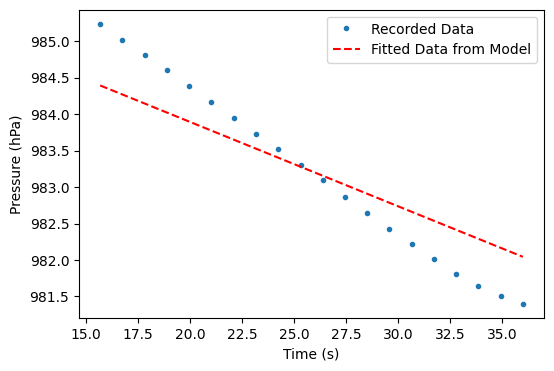

In [145]:
plt.figure(figsize=(6,4))
plt.plot(trimmed_df.time,trimmed_df.P,'.', label='Recorded Data')

heights = np.linspace(x.min(), x.max(), 100)
pressures = barometric_formula(P0=P0, height=heights)

plt.plot(heights, pressures, 'r--',label='Fitted Data from Model')

plt.xlabel("Time (s)")
plt.ylabel("Pressure (hPa)")
plt.legend()
plt.show()

In [166]:
#uncertainties

print(f'Uncertainty in time (s): {trimmed_df.time.std():.3f}')
print(f'Uncertainty in pressure (hPa): {df.P.std():.3f}')

height_uncertainty = elevator_speed * trimmed_df.time.std() # Assumes no uncertainty in elevator speed
print(f'Uncertainty in height (m): {height_uncertainty:.3f}')

P0_uncertainty = np.sqrt(np.diag(pcov))[0]
print(f'Uncertainty in P0 (hPa): {P0_uncertainty:.3f}')


Uncertainty in time (s): 6.326
Uncertainty in pressure (hPa): 1.769
Uncertainty in height (m): 6.326
Uncertainty in P0 (hPa): 0.114


## Part 4: Advanced Visualization (8 points)

### Task: Multi-Panel Figure

Create a **2×2 subplot grid**:

1. **Top-left:** Raw data vs time
2. **Top-right:** Fitted model vs time (overlay)
3. **Bottom-left:** Residuals (data - model)
4. **Bottom-right:** Histogram of residuals

**Requirements:**
- Shared x-axis (time) for top and bottom-left
- Proper axis labels with units
- Titles for each subplot
- Use `plt.subplots(2, 2, figsize=(12, 8))`

**Reference:** [Matplotlib subplots documentation](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html)

---

### Deliverable

- [ ] 2×2 figure with all four plots
- [ ] Residuals centered around zero (good fit)
- [ ] Histogram approximately Gaussian (if fit is good)

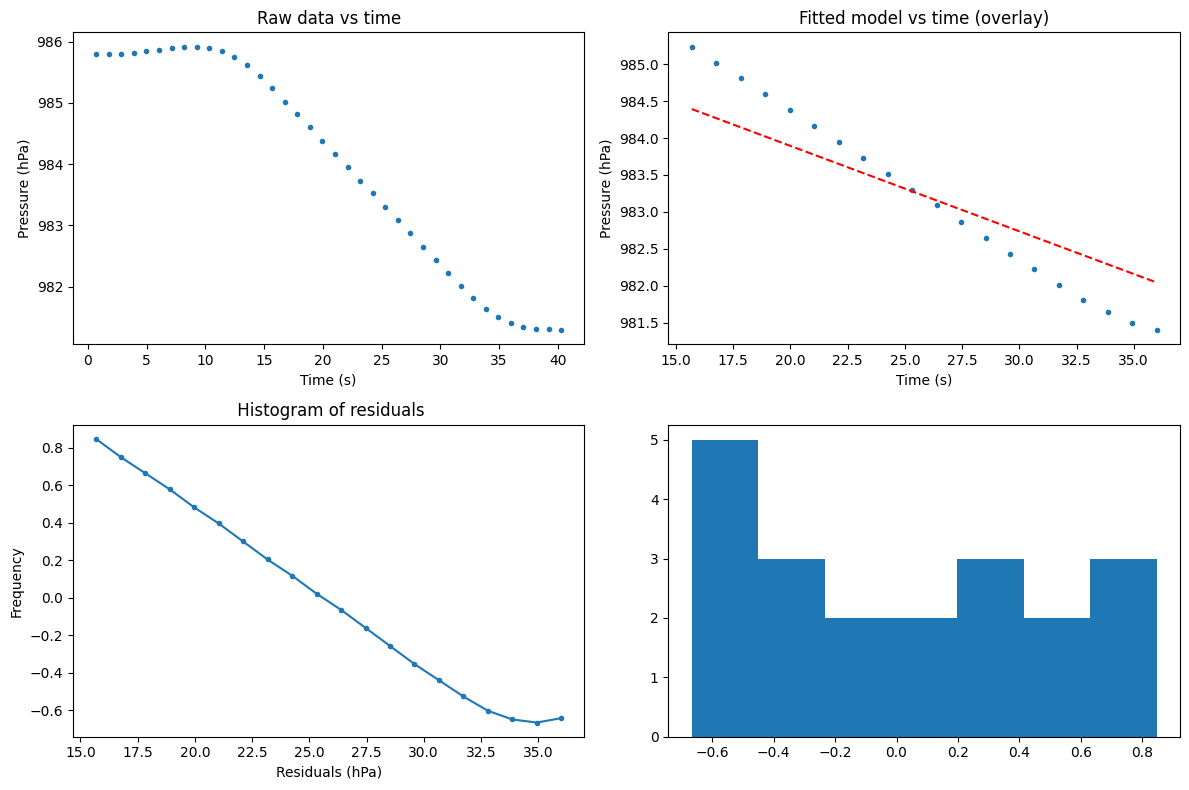

In [191]:
fig, axs = plt.subplots(2, 2, figsize=(12,8))
axs[0,0].plot(df.time, df.P, '.')
axs[0,0].set_xlabel("Time (s)")
axs[0,0].set_ylabel("Pressure (hPa)")
axs[0,0].set_title('Raw data vs time')

axs[0,1].plot(trimmed_df.time, trimmed_df.P,'.',label='Recorded Data')
axs[0,1].plot(heights, pressures, 'r--',label='Fitted Data from Model')
axs[0,1].set_xlabel("Time (s)")
axs[0,1].set_ylabel("Pressure (hPa)")
axs[0,1].set_title('Fitted model vs time (overlay)')

residuals = trimmed_df.P - barometric_formula(P0=P0, height=trimmed_df.height)
axs[1,0].plot(trimmed_df.time, residuals,'.-')
axs[1,0].set_xlabel("Time (s)")
axs[1,0].set_ylabel("Residuals (hPa)")
axs[1,0].set_title('Residuals (data - model) vs time')

axs[1,1].hist(residuals, bins=7)
axs[1,0].set_xlabel("Residuals (hPa)")
axs[1,0].set_ylabel("Frequency")
axs[1,0].set_title(' Histogram of residuals')

plt.tight_layout()
plt.show()


## Part 5: Error Analysis (8 points)

### Task: Uncertainty Quantification

1. **Parameter uncertainties**:
   - Extract from `curve_fit` covariance matrix: `np.sqrt(np.diag(pcov))`
   - Report fitted values ± uncertainty

2. **Sensor resolution**:
   - Check phyphox documentation or your CSV for precision
   - Example: Pressure typically ±0.1 hPa, gyroscope ±0.01 rad/s
   - How does sensor noise affect your fit?

3. **Systematic errors**:
   - **Pressure:** Local weather, sensor calibration
   - **Gyroscope:** Phone not level, chair friction varies
   - **Magnetometer:** Nearby metal objects, Earth's field
   - **Light:** Ambient light interference
   - **Microphone:** Background noise
   - **Proximity:** Non-linear sensor response

4. **Comparison to theory**:
   - Does your result match expected values?
   - Example: Barometric scale height should be ~8500 m
   - Example: Sound decay rate depends on room acoustics (no "correct" value, but should be positive)

---

### Deliverable

- [ ] Fitted parameters with uncertainties reported
- [ ] Discussion of sensor limitations (2-3 sentences)
- [ ] Comparison to expected/theoretical values (if applicable)
- [ ] List 2-3 sources of systematic error in your experiment

In [192]:
#1.

np.sqrt(np.diag(pcov))

array([0.11425493])

2. The phyphox barometer has a percission of $\pm$ 0.1hPa. This shouldn't make much of an impact since the recorded pressures were much larger than the percission limitations, but there may have been some small differenaces from what was measured.
>
Sensor noise likely didn't make an impact, having more data points would have led to a smaller uncertainy, but visually (even though different from the fit) the data points do seem to follow a linear pattern, which any sensor noise would probably have broken.

3. The weather would have had little effect on the measurements. Barometric pressures does change with the weather, but on the time scale of the measurements, there would have been little effect from weather changes. The sensors calibration could have also been off, causing the data points to be offset. Additionally, to keep consistancy, I left my phone on the ground of the elevator, so if my hands were shakey I would not affect the sensor. The data shows how the pressure initally rose before the elevator started moving which I assume is from my phone going from my hands to the ground.

4. The recorded data was a little off from the modeled fit. The pressure values also seem a little low, according to some weather sites, the barometric pressure seems to stay around $1009-1022$ hPa, so my values may have been low due to sensor calibration issues.

## Part 6: GitHub Workflow — Submit via Pull Request (10 points)

### NEW: Feature Branch Workflow (No Command Line!)

This homework introduces the **feature-branch workflow** using only the **GitHub website**. No terminal commands needed.

---

## ⚠️ IMPORTANT: Commit Messages Matter!

**You will lose points for non-descriptive commit messages.**

### Good Commit Messages ✅
- `Add data loading and preprocessing with pandas`
- `Implement exponential decay model for sound data`
- `Fix time axis trimming to remove setup period`
- `Create 2x2 subplot visualization with residuals`

### Bad Commit Messages ❌
- `update` (What did you update?)
- `fix` (What did you fix?)
- `stuff` (What stuff?)
- `asdf` (Not descriptive at all)
- `Final version` (Too vague)

### Why Commit Messages Matter:
- They document **what changed and why**
- They help reviewers understand your workflow
- They're essential in professional software development
- They help **you** remember what you did when you revisit code later

**Tip:** Write commit messages as if you're explaining to a classmate what you just did.

---

## Step-by-Step Instructions (GitHub Web Interface)

### Step 1: Go to the Repository

1. Open your browser and go to: [https://github.com/ubsuny/PHY386](https://github.com/ubsuny/PHY386)
2. Make sure you're logged into GitHub

---

### Step 2: Create Your Feature Branch

1. Click the **branch dropdown** (says "main" or "Homework2026")
2. Make sure **"Homework2026"** is selected
3. In the branch dropdown, type: `yourusername-hw3` (e.g., `jsmith-hw3`)
4. Click **"Create branch: yourusername-hw3 from Homework2026"**

![Create Branch](https://docs.github.com/assets/cb-32358/mw-1440/images/help/branches/branch-selection-dropdown.webp)

---

### Step 3: Upload Your Files

1. Make sure you're on **your branch** (check the dropdown says `yourusername-hw3`)
2. Navigate to: `2026/HW/yourusername/`
   - If your folder doesn't exist yet, create it by clicking **"Add file" → "Create new file"**
   - Name it `yourusername/.gitkeep` and commit (this creates the folder)
3. Click **"Add file" → "Upload files"**
4. Drag and drop:
   - `HW3.ipynb` (your completed notebook)
   - `yourusername_hw3_data.csv` (your raw data)
5. **At the bottom, write a DESCRIPTIVE commit message:**
   - Good: `Add HW3 notebook with gyroscope analysis and raw data`
   - Bad: `upload files`
6. Make sure **"Commit directly to yourusername-hw3 branch"** is selected
7. Click **"Commit changes"**

---

### Step 4: Open a Pull Request

1. After uploading, GitHub shows a yellow banner: **"yourusername-hw3 had recent pushes"**
2. Click the green **"Compare & pull request"** button

**OR** manually:
1. Click the **"Pull requests"** tab at the top
2. Click **"New pull request"**
3. Set:
   - **Base:** `Homework2026`
   - **Compare:** `yourusername-hw3`
4. Click **"Create pull request"**

---

### Step 5: Fill Out the PR Template

1. **Change the title** to: `HW3 - 2026 - yourusername`

2. **Fill out the description** (the template appears automatically):
   - Check **one** box under "Type of Submission":
     - `[ ]` In progress (if you want feedback)
     - `[x]` Final submission (if you're done)
   - Check all boxes in the Checklist
   - Fill in "What I implemented" section
   - Delete "Questions or notes" if you have none
   - Delete "AI Usage" if you didn't use AI

3. **Add label** (right sidebar):
   - Click **"Labels"**
   - Select: `homework-in-progress` OR `homework-final`

4. **Assign reviewer** (right sidebar):
   - Click **"Reviewers"**
   - Type: `laserlab` and select

5. **Set milestone** (right sidebar):
   - Click **"Milestone"**
   - Select: `HW3-2026`

6. Click **"Create pull request"**

---

### Step 6: Respond to Feedback

If the reviewer (in this case me) requests changes:

1. Go back to the repository
2. Switch to **your branch** (`yourusername-hw3`)
3. Navigate to your notebook file
4. Click the **pencil icon** ("Edit this file") if a text file or in google colab if a jupyter notebook
5. Make the requested changes
6. **Scroll down and commit with a DESCRIPTIVE message:**
   - Good: `Fix model function to use correct exponential form`
   - Good: `Add missing uncertainty calculations for fit parameters`
   - Bad: `fix`
7. The PR updates automatically
8. Go to your PR and **leave a comment**: "Ready for re-review @laserlab"

---

### Deliverable

- [ ] Feature branch created with correct naming (`yourusername-hw3`)
- [ ] Files uploaded to `2026/HW/yourusername/` in your branch
- [ ] **ALL commit messages are descriptive** (points will be deducted for vague messages)
- [ ] PR opened with title: `HW3 - 2026 - yourusername`
- [ ] PR template filled out completely
- [ ] Correct label added (`homework-in-progress` or `homework-final`)
- [ ] Reviewer assigned (`@laserlab`)
- [ ] Milestone set (`HW3-2026`)
- [ ] Responded to at least one round of feedback (if requested)


## Resources

- [phyphox Documentation](https://phyphox.org/)
- [phyphox Supported Sensors](https://phyphox.org/sensors/)
- [pandas Documentation](https://pandas.pydata.org/docs/)
- [scipy.optimize.curve_fit Guide](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)
- [Matplotlib Subplots](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html)
- [GitHub Pull Request Guide](https://docs.github.com/en/pull-requests/collaborating-with-pull-requests/proposing-changes-to-your-work-with-pull-requests/creating-a-pull-request)